# 14 Text Classification

In [82]:
import sys

if "google.colab" in sys.modules:
    print("Running in Colab!")
    !pip install unidecode

Running in Colab!


In [83]:
import os
import shutil
import string
import random
import pathlib
import unidecode
import collections
import regex as re

import numpy as np
import tensorflow as tf

import matplotlib.pyplot as plt
from IPython.display import clear_output

from IPython.core.magic import register_cell_magic

os.environ["KERAS_BACKEND"] = "jax"

import keras

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

---

## A brief history of natural language processing

The **big** story of recent years has been a move away from **hand-crafted features**.

Well until the 1990s the industry employed many linguists to implement specialist knowledge into rules for NLP systems.

Then, statistical approaches took over, especially with the rise of deep learning.

We leave aside the question of exactly **what** current systems understand from language.

What we know is that we can now train them to take in pieces of text, execute task on them.

- "What’s the topic of this text?" (**text classification**)  
- "Does this text contain abuse?" (**content filtering**)  
- "Does this text sound positive or negative?" (**sentiment analysis**)  
- "What should be the next word in this incomplete sentence?" (**language modeling**)  
- "How would you say this in German?" (**translation**)  
- "How would you summarize this article in one paragraph?" (**summarization**)


## Preparing text data

### Overview

- **standardisation**: make your text easier to process
- **splitting** (**tokenisation**): split into chunks (= tokens)
- **indexing**: turn chunks into numbers (indices in a fixed *vocabulary*)

#### Note: Text encoding

The question of **how language is represented** in computers is an important topic: if you're interested in working with language, do go and learn this!

The [**The Unicode Standard**](https://en.wikipedia.org/wiki/Unicode) is a world-wide consensus to associate characters of all languages with a unique identifier (a number), called a **code point**.

The Python documentation on [Unicode](https://docs.python.org/3/howto/unicode.html).

**Code points** can then be **encoded** in bits ([**UTF-8**](https://en.wikipedia.org/wiki/UTF-8), 8 bits, is one of the ways you can do that, and is backward-compatible with [**ASCII**](https://en.wikipedia.org/wiki/ASCII), 7 bits).

The reference has a very nice video summary on UTF-8.

### Text standardization

- Convert to **lower case**;  
- Remove **punctuation**;
- Convert **special characters** to a standard form (é → e);
- *Stemming*: turn **inflected forms** into base ones ("stares"/"stared"/"staring" → "[stare]")

In [84]:
s = "I didn't wake up this morning. How did that happen?"

In [85]:
s.lower()

"i didn't wake up this morning. how did that happen?"

In [86]:
"".join(char for char in s.lower() if char not in string.punctuation) # removing punctuation

'i didnt wake up this morning how did that happen'

In [87]:
def str_to_ints(s):
    # encode into bytes, then turn into a list
    s_enc = s.encode()
    print(f"{s} | {s_enc} | {list(s_enc)}")
s = "Jérémie"
str_to_ints(s)
str_to_ints(s.lower())
# removing anything
str_to_ints(unidecode.unidecode(s.lower()))

Jérémie | b'J\xc3\xa9r\xc3\xa9mie' | [74, 195, 169, 114, 195, 169, 109, 105, 101]
jérémie | b'j\xc3\xa9r\xc3\xa9mie' | [106, 195, 169, 114, 195, 169, 109, 105, 101]
jeremie | b'jeremie' | [106, 101, 114, 101, 109, 105, 101]


### Text splitting (tokenization)

We will cover three very common schemes:

- **character-level tokenization**: split on characters;
- **word-level tokenization**: split on spaces;
- **subword tokenization**: split based on frequency of character clusters (can be characters, parts of words, words, phrases)

Note also:
- **n-gram tokenization**: tokenize using the scheme of your choice, then create groups of length `n` ('abcd' -> 'a,b,c,d' -> 'ab,'bc','cd';
- **byte-level tokenization**: split on bytes.

You will note the use of the [`regex`](https://pypi.org/project/regex/) ("REGular EXpression") module (an updated version of the default [`re`](https://docs.python.org/3/library/re.html) package in Python). Regular expressions are *very* useful for any text manipulation: tutorials [here](https://realpython.com/regex-python/), [here](https://realpython.com/regex-python-part-2/) and [here](https://docs.python.org/3/howto/regex.html))

In [88]:
s = "the quick brown fox jumps over the lazy dog"

In [89]:
def split_chars(text):
    # return re.findall(r".", text)
    # an order of magnitude faster...
    return list(text)

In [90]:
chars = split_chars("The quick brown fox jumped over the lazy dog.")
chars[:12]

['T', 'h', 'e', ' ', 'q', 'u', 'i', 'c', 'k', ' ', 'b', 'r']

In [91]:
def split_words(text):
    # '\w' any "word character"
    # '+' appearing once or more
    # '|' or
    # [] any char inside the brackets (punctuation)
    return re.findall(rf"\w+|[{string.punctuation}]", text)

In [92]:
# the punctuation characters we isolate in the regex
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [93]:
split_words("The quick brown fox jumped over the dog.")

['The', 'quick', 'brown', 'fox', 'jumped', 'over', 'the', 'dog', '.']

### Vocabulary indexing

From a dataset, we create a big table **associating each word with a number**.

We can also add special information like an index for:
- **unknown words** ("\[UNK\]" for *unknown*, aka OOV: out of vocabulary);
- **beginning of sentence** ("bos");
- **end of sentence** ("eos");
- **padding** ("\[PAD\]", to make sequences the same length);
- **masked token**, and other customised "special tokens" depending on needs...

In [94]:
vocabulary = {
    "[UNK]": 0,
    "the": 1,
    "quick": 2,
    "brown": 3,
    "fox": 4,
    "jumped": 5,
    "over": 6,
    "dog": 7,
    ".": 8,
}
words = split_words("The quick brown fox jumped over the lazy dog.")
indices = [vocabulary.get(word, 0) for word in words]

In [95]:
indices

[0, 2, 3, 4, 5, 6, 1, 0, 7, 8]

In [96]:
reverse_vocab = {v:k for k,v in vocabulary.items()}

print(" ".join([reverse_vocab[i] for i in indices]))

[UNK] quick brown fox jumped over the [UNK] dog .


The full pipeline:

<!-- <img style="height: 400px" src="images/chollet/figure14.1.png"> -->
<img style="height: 400px" src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/07/images/chollet/figure14.1.png">

[DLWP](https://deeplearningwithpython.io/chapters/chapter14_text-classification/#preparing-text-data), Figure 14.1

### Types of tokenzation

#### Char tokenization

In this first example, we'll isolate every character in the text, and map that to one integer.

In [97]:
class CharTokenizer:
    def __init__(self, vocabulary):
        self.vocabulary = vocabulary
        self.unk_id = vocabulary["[UNK]"]

    def standardize(self, inputs):
        return inputs.lower()

    def split(self, inputs):
        # an order of magnitude faster than using regex...
        return list(inputs)
        # return re.findall(r".", inputs)

    def index(self, tokens):
        # translate back into strings using our vocab, with '[UNK]' as fallback
        return [self.vocabulary.get(t, self.unk_id) for t in tokens]

    def __call__(self, inputs):
        # the standardization is to simplify things, but you could remove it as well
        inputs = self.standardize(inputs)
        # split into characters
        tokens = self.split(inputs)
        # convert from characters to integers
        indices = self.index(tokens)
        return indices

In [98]:
def compute_char_vocabulary(inputs, max_size):
    char_counts = collections.Counter()
    for x in inputs:
        # same optional standardization step as before
        x = x.lower()
        # an order of magnitude faster than using regex...
        tokens = list(x)
        # tokens = re.findall(r".", x)
        char_counts.update(tokens)
    vocabulary = ["[UNK]"]
    # get the most common minus 1 (we already have '[UNK]')
    most_common = char_counts.most_common(max_size - len(vocabulary))
    for token, count in most_common:
        vocabulary.append(token)
    return dict((token, i) for i, token in enumerate(vocabulary))

#### Word tokenization

Then, if we use the same splitting method as before (on words – `\w+`, "one or more word character" in regex –, or any punctuation character), our vocabulary will be much larger, but the resulting encoding will be shorter

In [99]:
class WordTokenizer:
    def __init__(self, vocabulary):
        self.vocabulary = vocabulary
        self.unk_id = vocabulary["[UNK]"]

    def standardize(self, inputs):
        return inputs.lower()

    def split(self, inputs):
        # split into either words or punctuation signs ('[]' means match 'any of the characters inside')
        return re.findall(rf"\w+|[{string.punctuation}]", inputs)

    def index(self, tokens):
        # translate back into strings using our vocab, with '[UNK]' as fallback
        return [self.vocabulary.get(t, self.unk_id) for t in tokens]

    def __call__(self, inputs):
        # the standardization is to simplify things, but you could remove it as well
        inputs = self.standardize(inputs)
        # split into words (and/or punct)
        tokens = self.split(inputs)
        # convert tokens into integers
        indices = self.index(tokens)
        return indices

In [100]:
def compute_word_vocabulary(inputs, max_size):
    word_counts = collections.Counter()
    for x in inputs:
        # same optional standardization step as before
        x = x.lower()
        # split into either words or punctuation signs ('[]' means match 'any of the characters inside')
        tokens = re.findall(rf"\w+|[{string.punctuation}]", x)
        word_counts.update(tokens)
    vocabulary = ["[UNK]"]
    if max_size > 0:
        # get the most common minus 1 (we already have '[UNK]')
        most_common = word_counts.most_common(max_size - len(vocabulary))
    else:
        # for max_size == 0, get everything
        most_common = word_counts.most_common()
    for token, count in most_common:
        vocabulary.append(token)
    return dict((token, i) for i, token in enumerate(vocabulary))

#### Test our tokenizers so far

Here we use Melville's [Moby Dick](https://www.gutenberg.org/ebooks/2701), but feel free to try other texts as well!

[`keras.utils.get_file` documentation](https://keras.io/api/utils/python_utils/#getfile-function)

In [101]:
filename = keras.utils.get_file(
    origin="https://www.gutenberg.org/cache/epub/2701/pg2701.txt",
)

with open(filename, "r") as i:
    # this automatically splits into lines
    moby_dick = list(i)

##### Char tokenizer

Small vocabulary, longer encoding!

In [102]:
vocabulary = compute_char_vocabulary(moby_dick, max_size=100)
char_tokenizer = CharTokenizer(vocabulary)

In [103]:
print("Vocabulary length:", len(vocabulary))

Vocabulary length: 80


In [104]:
print("Vocabulary start:", list(vocabulary.keys())[:10])

Vocabulary start: ['[UNK]', ' ', 'e', 't', 'a', 'o', 'n', 'i', 's', 'h']


In [105]:
print("Vocabulary end:", list(vocabulary.keys())[-10:])

Vocabulary end: ['ח', 'ו', '\u200e', 'ϰ', 'η', 'τ', 'ο', 'ς', 'â', '%']


In [106]:
print("Line length:", len(char_tokenizer(
   "Call me Ishmael. Some years ago--never mind how long precisely."
)))

Line length: 63


##### Word tokenizer

Large vocabulary, but shorter encoding!

In [107]:
# you could try max_size=0: even larger vocab, although for the example sentence below it wouldn't change anything
vocabulary = compute_word_vocabulary(moby_dick, max_size=2_000)
word_tokenizer = WordTokenizer(vocabulary)

In [108]:
print("Vocabulary length:", len(vocabulary))

Vocabulary length: 2000


In [109]:
print("Vocabulary start:", list(vocabulary.keys())[:5])

Vocabulary start: ['[UNK]', ',', 'the', '.', 'of']


In [110]:
print("Vocabulary end:", list(vocabulary.keys())[-5:])

Vocabulary end: ['barbaric', 'helmsman', 'temporary', 'indispensable', 'fashion']


In [111]:
print("Line length:", len(word_tokenizer(
   "Call me Ishmael. Some years ago--never mind how long precisely."
)))

Line length: 15


#### Subword tokenization

In [112]:
data = [
    "the quick brown fox",
    "the slow brown fox",
    "the quick brown foxhound",
]

In [113]:
def count_and_split_words(data, apply_standardization=False):
    counts = collections.Counter()
    for line in data:
        # in production system, no standardization is applied!
        if apply_standardization:
            line = line.lower()
        # for each match (a word or a punctuation sign)
        for match in re.finditer(rf"\w+|[{string.punctuation}]", line):
            word = match.group()
            start = match.start()
            # ignore the beginning of the string, then if char at start is preceded by space, create prefix
            prefix = "Ġ" if start > 0 and line[start - 1].isspace() else ""
            # decompose into chars
            # chars = re.findall(r".", word)
            # decompose into chars (list(word)), but include the prefix with the first char
            chars = ([prefix + word[0]] + list(word[1:])) if word else []
            # rejoin into a string with spaces between
            split_word = " ".join(chars)
            # add the split word to the counter
            counts[split_word] += 1

            # print(f"{match=} | {word=} | {chars=}")

    return dict(counts)

counts = count_and_split_words(data)

In [114]:
counts

{'t h e': 3,
 'Ġq u i c k': 2,
 'Ġb r o w n': 3,
 'Ġf o x': 2,
 'Ġs l o w': 1,
 'Ġf o x h o u n d': 1}

In [115]:
def count_pairs(counts):
    # create a counter for pairs of symbols
    pairs = collections.Counter()
    # for all words
    for word, freq in counts.items():
        # split on space -> symbols (chars or char groups)
        symbols = word.split()
        # each time a pair of symbols appears, add the frequency of the word it appears in
        for pair in zip(symbols[:-1], symbols[1:]):
            pairs[pair] += freq
    return pairs

def merge_pair(counts, first, second):
    # regex:
    # - (?<!A)B find B if not (!) preceded (<) by A
    # - A(?!B) find A if not (!) preceding B
    # for first=ab, second=cd, will match a string
    # with [any space]ab cd[any space], so
    # '... ab cd ...', but not '...ab cd...'
    # (the double \\ is required to escape – make valid – the \)
    split = re.compile(fr"(?<!\S){first} {second}(?!\S)")
    merged = f"{first}{second}"
    # we find 'X ab cd Y', and substitute it with 'X abcd Y', in all words
    return {split.sub(merged, word): count for word, count in counts.items()}

In [116]:
# the number 5 is arbitrary:
counts_bpe = counts.copy()
for i in range(5):

    pairs = count_pairs(counts_bpe)
    # first, second = max(pairs, key=pairs.get)
    [(first, second), freq] = pairs.most_common(n=1)[0]

    print(f"{i+1} | merging: {first} {second} → {first}{second} ({freq} occurrences)")
    print()
    print(f"{list(counts_bpe.keys())}")

    counts_bpe = merge_pair(counts_bpe, first, second)

    print(f"{list(counts_bpe.keys())}")
    print()
    print("-" * 20)
    print()

1 | merging: o w → ow (4 occurrences)

['t h e', 'Ġq u i c k', 'Ġb r o w n', 'Ġf o x', 'Ġs l o w', 'Ġf o x h o u n d']
['t h e', 'Ġq u i c k', 'Ġb r ow n', 'Ġf o x', 'Ġs l ow', 'Ġf o x h o u n d']

--------------------

2 | merging: t h → th (3 occurrences)

['t h e', 'Ġq u i c k', 'Ġb r ow n', 'Ġf o x', 'Ġs l ow', 'Ġf o x h o u n d']
['th e', 'Ġq u i c k', 'Ġb r ow n', 'Ġf o x', 'Ġs l ow', 'Ġf o x h o u n d']

--------------------

3 | merging: th e → the (3 occurrences)

['th e', 'Ġq u i c k', 'Ġb r ow n', 'Ġf o x', 'Ġs l ow', 'Ġf o x h o u n d']
['the', 'Ġq u i c k', 'Ġb r ow n', 'Ġf o x', 'Ġs l ow', 'Ġf o x h o u n d']

--------------------

4 | merging: Ġb r → Ġbr (3 occurrences)

['the', 'Ġq u i c k', 'Ġb r ow n', 'Ġf o x', 'Ġs l ow', 'Ġf o x h o u n d']
['the', 'Ġq u i c k', 'Ġbr ow n', 'Ġf o x', 'Ġs l ow', 'Ġf o x h o u n d']

--------------------

5 | merging: Ġbr ow → Ġbrow (3 occurrences)

['the', 'Ġq u i c k', 'Ġbr ow n', 'Ġf o x', 'Ġs l ow', 'Ġf o x h o u n d']
['the', 'Ġq

In [117]:
def compute_sub_word_vocabulary(dataset, n_merges, apply_standardization=True):
    counts = count_and_split_words(dataset, apply_standardization=apply_standardization)

    char_counts = collections.Counter()
    for word in counts:
        for char in word.split():
            char_counts[char] += counts[word]
    most_common = char_counts.most_common()
    # add the unknown token at the star
    vocab = ["[UNK]"] + [char for char, freq in most_common]
    v_l = len(vocab)
    print(f"vocab size before merging: {v_l}")

    merges = []

    # continue merging until we have either merged everything or reached our vocab size
    while len(vocab) < n_merges:
        pairs = count_pairs(counts)
        if not pairs:
            break
        # find the most frequent pair
        first, second = max(pairs, key=pairs.get)
        # merge the pair in all words
        counts = merge_pair(counts, first, second)
        # append the merged pair as token,
        vocab.append(f"{first}{second}")
        # and the merge itself (we need that to decode!)
        merges.append(f"{first} {second}")

        clear_output(wait=True)
        print(f"vocab size before merging: {v_l}")
        print(f"{len(vocab)}/{n_merges}")
    else:
        print(f"vocab size now: {len(vocab)}")

    vocab = dict((token, index) for index, token in enumerate(vocab))
    # note the 'rank': the most frequent merge comes first in our list
    merges = dict((token, rank) for rank, token in enumerate(merges))
    return vocab, merges

In [118]:
apply_standardization=False
vocabulary, merges = compute_sub_word_vocabulary(moby_dick, 2000, apply_standardization=apply_standardization)

vocab size before merging: 162
2000/2000
vocab size now: 2000


In [119]:
print("Vocabulary length:", len(vocabulary))
print("Vocabulary start:", list(vocabulary.keys())[:10])
print("Vocabulary end:", list(vocabulary.keys())[-7:])

Vocabulary length: 2000
Vocabulary start: ['[UNK]', 'e', 'n', 'o', 'a', 't', 'i', 'h', 'r', 's']
Vocabulary end: ['Ġshow', 'Ġwondrous', 'Ġgun', 'Ġencoun', 'Ġcopy', 'ĠChrist', 'keleton']


In [120]:
print("Merges length:", len(merges))
print("Merges start:", list(merges.keys())[:10])
print("Merges end:", list(merges.keys())[-7:])

Merges length: 1838
Merges start: ['h e', 'Ġt he', 'i n', 'e r', 'n d', 'a t', 'e d', 'in g', 'r e', 'o u']
Merges end: ['Ġsh ow', 'Ġwond rous', 'Ġg un', 'Ġen coun', 'Ġcop y', 'ĠCh rist', 'kelet on']


In [121]:
class SubWordTokenizer:
    def __init__(self, vocabulary, merges, apply_standardization=True):
        self.vocabulary = vocabulary
        self.invert_vocab = {v:k for k, v in self.vocabulary.items()}
        self.merges = merges
        self.unk_id = vocabulary["[UNK]"]
        self.apply_standardization = apply_standardization

    def standardize(self, inputs):
        return inputs.lower()

    def bpe_merge(self, word):
        while True:
            # Matches all symbol pairs in the text
            pairs = re.findall(r"(?<!\S)\S+ \S+(?!\S)", word, overlapped=True)
            if not pairs:
                break
            # We apply merge rules in "rank" order. More frequent pairs
            # are merged first → they have the lowest rank
            best = min(pairs, key=lambda pair: self.merges.get(pair, 1e9))
            if best not in self.merges:
                break
            first, second = best.split()
            split = re.compile(rf"(?<!\S){first} {second}(?!\S)")
            merged = f"{first}{second}"
            word = split.sub(merged, word)
        return word

    def split(self, inputs):
        tokens = []
        # Split words
        for match in re.finditer(rf"\w+|[{string.punctuation}]", inputs):
            word = match.group()
            start = match.start()
            # ignore the beginning of string, then: if first match char is preceded by space, create prefix
            prefix = "Ġ" if start > 0 and inputs[start - 1].isspace() else ""
            # decompose into chars (list(word)), but include the prefix with the first char
            word = " ".join([prefix + word[0]] + list(word[1:]))
            # Applies byte-pair encoding merge rules
            word = self.bpe_merge(word)
            tokens.extend(word.split())
        return tokens

    def index(self, tokens):
        return [self.vocabulary.get(t, self.unk_id) for t in tokens]

    def __call__(self, inputs):
        if self.apply_standardization:
            inputs = self.standardize(inputs)
        tokens = self.split(inputs)
        indices = self.index(tokens)
        return indices

    def detokenize(self, token_ids):
        # we assume here that "Ġ" only appears as a substitute of space...
        return "".join(self.invert_vocab[i] for i in token_ids).replace("Ġ", " ")

In [122]:
sub_word_tokenizer = SubWordTokenizer(vocabulary, merges, apply_standardization=apply_standardization)

In [123]:
tokenized_s = sub_word_tokenizer(
   "Call me Ishmael. Some years ago--never mind how long precisely."
)
print(tokenized_s)
print("Line length:", len(tokenized_s))

[71, 241, 289, 45, 485, 1568, 273, 29, 49, 269, 1090, 363, 3, 44, 44, 2, 393, 1094, 559, 476, 1376, 530, 193, 29]
Line length: 24


In [124]:
sub_word_tokenizer.detokenize(tokenized_s)

'Call me Ishmael. Some years ago--never mind how long precisely.'

Note that an important piece of the pipeline is missing: in production versions of BPE, the tokenizer computes the merges on raw bytes, and always includes, as a 'backup', the minimal 256 tokens vocabulary (all possibilities for one byte), which means that in the worst case, it will always be able to encode/decode sequences without resorting to '[UNK]'. See the reference notebook for ressources to learn more about this!

---

## Sets vs sequences

- Sets: "bag of words", the order is lost.  
- Sequences: order/time matters!

### Preparing the IMDB movie reviews data

#### Downloading the data & organise the directory

In [131]:
DATASET_DIR = pathlib.Path("aclImdb")

if not DATASET_DIR.exists():
    !curl -O https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
    !tar -xf aclImdb_v1.tar.gz # this untars the archive to a folder called aclImdb
    !rm -r aclImdb/train/unsup

MODELS_DIR = pathlib.Path("models")
MODELS_DIR.mkdir(exist_ok=True)

In [132]:
!cat aclImdb/train/pos/4077_10.txt

I first saw this back in the early 90s on UK TV, i did like it then but i missed the chance to tape it, many years passed but the film always stuck with me and i lost hope of seeing it TV again, the main thing that stuck with me was the end, the hole castle part really touched me, its easy to watch, has a great story, great music, the list goes on and on, its OK me saying how good it is but everyone will take there own best bits away with them once they have seen it, yes the animation is top notch and beautiful to watch, it does show its age in a very few parts but that has now become part of it beauty, i am so glad it has came out on DVD as it is one of my top 10 films of all time. Buy it or rent it just see it, best viewing is at night alone with drink and food in reach so you don't have to stop the film.<br /><br />Enjoy

In [133]:
# code to split the data into train/val folders

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"
TEST_DIR = DATASET_DIR / "test"
for category in ("neg", "pos"):
    if not os.path.isdir(VAL_DIR / category):    # do this only once
        os.makedirs(VAL_DIR / category)          # make 'neg'/'pos' dir in validation
        files = os.listdir(TRAIN_DIR / category) # list files in 'train'
        random.Random(1337).shuffle(files)       # shuffle using a seed
        num_val_samples = int(0.2 * len(files))  # 2% of our samples for validation
        val_files = files[-num_val_samples:]
        for fname in val_files:                  # move our files
            shutil.move(TRAIN_DIR / category / fname,
                        VAL_DIR / category / fname)

#### Process using `text_dataset_from_directory`

See the [documentation](https://keras.io/api/data_loading/text/) (similar Keras helper functions to create a [Tensorflow Dataset](https://www.tensorflow.org/api_docs/python/tf/data/Dataset) as `image_dataset_from_directory` we've seen).


```bash
$ tree -d 1 aclImdb
├── aclImdb
│   ├── test
│   │   ├── neg
│   │   └── pos
│   ├── train
│   │   ├── neg
│   │   └── pos
│   └── validation
│       ├── neg
│       └── pos
```

In [134]:
BATCH_SIZE = 32

# each of these iterables returns tuples containing two tensors:
# samples, shape: (batch_size, sample_shape) ← our texts
# targets, shape: (batch_size,)              ← 0 or 1
train_ds = keras.utils.text_dataset_from_directory(
    TRAIN_DIR, batch_size=BATCH_SIZE
)
val_ds = keras.utils.text_dataset_from_directory(
    VAL_DIR, batch_size=BATCH_SIZE
)
test_ds = keras.utils.text_dataset_from_directory(
    TEST_DIR, batch_size=BATCH_SIZE
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.


In [135]:
for inputs, targets in train_ds:            # displaying the shapes and dtypes of the first batch
    print("inputs.shape:", inputs.shape)
    print("inputs.dtype:", inputs.dtype)
    print("targets.shape:", targets.shape)
    print("targets.dtype:", targets.dtype)
    print()
    print("targets[0]:", targets[0].numpy())
    print()
    print("inputs[0]:", inputs[0].numpy())
    break

inputs.shape: (32,)
inputs.dtype: <dtype: 'string'>
targets.shape: (32,)
targets.dtype: <dtype: 'int32'>

targets[0]: 1

inputs[0]: b'Another good Stooge short!Christine McIntyre is so lovely and evil and the same time in this one!She is such a great actress!The Stooges are very good and especially Shemp and Larry!This to is a good one to watch around Autumn time!'


---

## Set models

### Training a bag-of-words model

#### Bag-of-words (unigrams), multi-hot encoding

- bag-of-word (unigram): first you split, then take each split on its own
- binary encoding: multi-hot
- the order is lost

The same set-up as when dealing with IMDB before (we did it manually then).

In [136]:
max_tokens = 20_000
# preprocessing our datasets with a `TextVectorization` layer
text_vectorization = keras.layers.TextVectorization(
    # cap the vocab size to 20k
    max_tokens=max_tokens,
    # a 1 at the index of each word present, 0 otherwise
    output_mode="multi_hot",
    # the default
    split="whitespace",
    # the default (↔ unigram)
    ngrams=None,
)

# we must build our text encoding layer to the text at hand (build the vocab, etc.
# for that, we 1) create a sub-dataset that returns only the text
text_only_train_ds = train_ds.map(lambda x, y: x)
# then 2) we use `.adapt` on it
text_vectorization.adapt(text_only_train_ds)

##### Tests

In [137]:
# unigram == bag of words (BOW)
set("the cat sat on the mat".split())

{'cat', 'mat', 'on', 'sat', 'the'}

In [138]:
vocabulary = text_vectorization.get_vocabulary()
inverse_vocab = dict(enumerate(vocabulary))

We get a multi-hot vector, with `1` at the index of the words present.

In [139]:
cat = text_vectorization("the cat")
print(cat.numpy(), cat.shape)                                    # "the cat" is now a vector of 20000 zeros
                                                                 #  with 1s at the index of "the" and "cat"
print()
indz = tf.where(cat > 0)                                         # retrieving the indices of the words
print(indz.numpy())
print()
print(" ".join([inverse_vocab[i.numpy().item()] for i in indz])) # retranslating back into a string

[0 1 0 ... 0 0 0] (20000,)

[[   1]
 [1165]]

the cat


In [140]:
vocabulary.index("cat"), inverse_vocab[1162]

(1165, np.str_('depth'))

In [141]:
cat = text_vectorization("the cute cat")
print(cat.numpy(), cat.shape)
print()
indz = tf.where(cat > 0)
print(indz.numpy())
print()
print(" ".join([inverse_vocab[i.numpy().item()] for i in indz]))

[0 1 0 ... 0 0 0] (20000,)

[[   1]
 [1000]
 [1165]]

the cute cat


In [142]:
vocabulary.index("cute"), inverse_vocab[1061]

(1000, np.str_('crew'))

#### Dataset

In [143]:
bag_of_words_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4
)
bag_of_words_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4
)
bag_of_words_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4
)

In [144]:
for inputs, targets in bag_of_words_train_ds: # inspecting the output of our binary unigram dataset
    print("inputs.shape:", inputs.shape)
    print("inputs.dtype:", inputs.dtype)
    print("targets.shape:", targets.shape)
    print("targets.dtype:", targets.dtype)
    print()
    print("targets[0]:", targets[0].numpy())
    print()
    print("inputs[0]:", inputs[0].numpy())
    break

inputs.shape: (32, 20000)
inputs.dtype: <dtype: 'int64'>
targets.shape: (32,)
targets.dtype: <dtype: 'int32'>

targets[0]: 0

inputs[0]: [1 1 0 ... 0 0 0]


#### Model

In [145]:
def build_linear_classifier(max_tokens, name, clear=True):
    """
    Our model-building utility
    """
    if clear:
        keras.backend.clear_session()
    inputs = keras.Input(shape=(max_tokens,))
    outputs = keras.layers.Dense(1, activation="sigmoid")(inputs)
    model = keras.Model(inputs, outputs, name=name)
    model.compile(
        optimizer="adam",
        # our labels are only 0 or 1 (negative/positive)
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [146]:
# Training the binary unigram model
model = build_linear_classifier(max_tokens, "bag_of_words_classifier")
model.summary()

Model: "bag_of_words_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        20,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,001 (78.13 KB)

 Trainable params: 20,001 (78.13 KB)

 Non-trainable params: 0 (0.00 B)

#### Training

In [147]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    restore_best_weights=True,
    patience=2,
)

history = model.fit(
    bag_of_words_train_ds.cache(),
    validation_data=bag_of_words_val_ds.cache(),
    epochs=10,
    callbacks=[early_stopping],
    verbose=0,
)

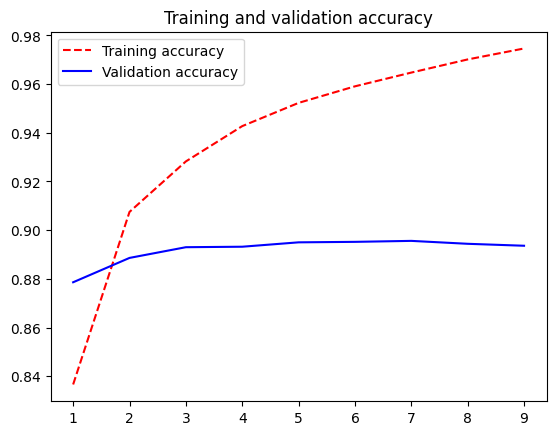

In [148]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.show()

In [149]:
# And testing it
_, test_acc = model.evaluate(bag_of_words_test_ds)
print(f"Test acc: {test_acc:.3f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8826 - loss: 0.2916
Test acc: 0.883


In [150]:
del (
    model, text_vectorization,
    bag_of_words_train_ds, bag_of_words_val_ds, bag_of_words_test_ds
)

### Training a bigram model

#### Bigrams (splitting → grouping by two), multi-hot encoding

- bigram: first you split, then take tokens two by two   
- binary encoding: multi-hot (each bigram is one token!)
- *almost all* order is lost

In [151]:
max_tokens = 30_000
text_vectorization = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="multi_hot",
    # the default
    split="whitespace",
    # returns bigrams
    ngrams=2,
)

text_vectorization.adapt(text_only_train_ds)

##### Tests

In [152]:
vocabulary = text_vectorization.get_vocabulary()
print(f"{len(vocabulary)} tokens in the vocabulary")

# displaying the vocabulary: note the groups of two words!
print([x.item() for x in vocabulary[100:108]])

30000 tokens in the vocabulary
['great', 'most', 'it was', 'him', 'dont', 'one of', 'then', 'made']


In [153]:
encoded_sentence = text_vectorization("I write, rewrite, and still rewrite again")
print(encoded_sentence)

tf.Tensor([1 0 1 ... 0 0 0], shape=(30000,), dtype=int64)


#### Dataset

In [154]:
bigram_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)
bigram_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)
bigram_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)

#### Model, training

In [155]:
# Training the binary bigram model
model = build_linear_classifier(max_tokens, "bigram_classifier")

history = model.fit(
    bigram_train_ds.cache(),
    validation_data=bigram_val_ds.cache(),
    epochs=10,
    callbacks=[early_stopping],
    verbose=0,
)

In [156]:
#  and testing
_, test_acc = model.evaluate(bigram_test_ds)
print(f"Test acc: {test_acc:.3f}") # better than the unigram model

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9024 - loss: 0.2540
Test acc: 0.900


In [157]:
del (
    model, text_vectorization,
    bigram_train_ds, bigram_val_ds, bigram_test_ds
)
keras.backend.clear_session()

## Sequence models

### Word embeddings

A big revolution of this last decade: researchers discovered that we can get systems to **learn to project words** into a **vector space** that retain **semantic relationship**.

The idea behind this discovery is that **similar words** (similar meanings) occur in **similar contexts**.

*You shall know a word by the company it keeps.*  
(J. R. Firth, "A Synopsis of Linguistic Theory", 1957, cf. also [the late Wittgenstein](https://plato.stanford.edu/entries/wittgenstein/#MeanUse))

The algorithms will train on large text corpora, and:
- count all the occurrences of words and contexts;  
- try and predict either the word given the context;
- or the context given the word.

Word embeddings in the context of a large dictionary have typically 256, 512 or 1024 dimensions  
(the dimension of a vector is its length i.e. the number of components).

One-hot encoded vectors can exceed 20,000 dimensions!  
Also, technically all one-hot encoded are **orthogonal**: no similarity between them.

Word embeddings compress the information into fewer dimensions.  
Two word vectors can be compared to each other!

<!-- <img style="height: 400px" src="images/chollet/figure14.3.png"> -->
<img style="height: 400px" src="https://github.com/jchwenger/DLWP/blob/main/lectures/07/images/chollet/figure14.3.png?raw=true">

[DLWP](https://deeplearningwithpython.io/chapters/chapter14_text-classification/#understanding-word-embeddings), Figure 14.3

|One-hot|Word embeddings|
|:---|:---|
|binary (integers: 0/1)|floating point vectors|
|sparse (most elements are zeros)|*dense*|
|very high-dimensional|low-to-medium-dimensional|
|hard-coded|learnt from data|


The results is that each token will be represented as a **coordinate** (aka a **vector**) in a high-dimensional space.

The most striking features of these spaces is that they seem to encode **semantic relationships**!

<!-- <img src="images/nlp/linear-relationships.svg"> -->
<img src="https://github.com/jchwenger/DLWP/blob/main/lectures/07/images/nlp/linear-relationships.svg?raw=true">


<small>[Embeddings: Translating to a Lower-Dimensional Space, Google Foundational Courses, Machine Learning, Embeddings](https://developers.google.com/machine-learning/crash-course/embeddings/translating-to-a-lower-dimensional-space)</small>

#### Note: universal embedding

A universal embedding is unlikely, or very difficult to achieve (although [recent work](https://phillipi.github.io/prh/) proposes the opposite conjecture, thanks Peyton Hammersley for the references).

Semantic relationships depend on task – the text corpus and what we are learning.

Expect different geometries for different tasks (e.g. sentiment analysis is very different from classification of legal documents).

#### Also: bias

The biases of your dataset **will be encoded** in the space (for instance, gendered associations between professions).

#### Learning word embeddings with the Embedding layer

<!-- <img style="height: 400px" src="images/chollet/figure14.5.png"> -->
<img style="height: 400px" src="https://github.com/jchwenger/DLWP/blob/main/lectures/07/images/chollet/figure14.5.png?raw=true">

[DLWP](https://deeplearningwithpython.io/chapters/chapter14_text-classification/#using-a-word-embedding), Figure 14.5

Later, researchers discovered that you can simply **learn** these vectors with your DL model using backprop like everything else!

In current models, you just invoke a specific layer, and all the work is done for you.

Note that you must specify in advance the **dimensionality** of the embedding space.

As usual, more dimensions == more **resolution** (finer-grained), but more computationally expensive.

In [158]:
max_tokens = 8000
inputs = keras.Input(shape=(max_tokens,))
embedding_layer = keras.layers.Embedding( # ← EMBEDDING LAYER
    input_dim=max_tokens,                    # the size of the vocabulary (8000)
    output_dim=256                           # the dimensionality of the embedding space
)
x = embedding_layer(inputs)
model = keras.Model(inputs, x)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 8000, 256)      │     2,048,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,048,000 (7.81 MB)

 Trainable params: 2,048,000 (7.81 MB)

 Non-trainable params: 0 (0.00 B)

The two arguments of the embedding layer code are:

```python
keras.layers.Embedding(input_dim=max_tokens, output_dim=256)
```

- input_dim = 8000 (the size of our vocab)
- output_dim = 256 (the dimension of the embedding space)

In Chollet's example (the IMDB sentiment task again), reviews have been reduced (or expanded) to a constant length of 600 words.

E.g. `x_test[0] = [65, 16, 38, 1334, 88, 12, ..., 16, 5345, 19, 178, 32]`

65, 16, 38... are dictionary entries – word 65, word 16, word 38... in the 8000-words dictionary.

The `Embedding` layers creates a matrix of randomly initialised vectors, one for each word: $d_{vocab} \times d_{embedding}$.

Then, each elements of `x_test[0]` is used as an index to retrieve the appropriate embedding vector => 600 vectors of dimensions $256$.

#### Note: one-hot vector matrix multiplication as index retrieval

The actual operation implemented in `Keras` and other libraries does not, to my knowledge, use this, as it would require the allocation of a large sparse matrix, but it is worth noting that if your word index is encoded as a one-hot vector, a matrix multiplication will in effect retrieve the vector in the corresponding row:


$$
\begin{bmatrix}
0 & \cdots & 1_{\text{col r}} & \cdots & 0\\
\end{bmatrix}
\overbrace{
\begin{bmatrix}
\text{e}_{11} & \cdots & \text{e}_{1d_e}\\
\vdots & & \vdots \\
\color{red}{\text{e}_{r1}} & \cdots & \color{red}{\text{e}_{rd_e}} \\
\vdots & & \vdots \\
\text{e}_{d_v1} & \cdots &\text{e}_{d_vd_e}\\
\end{bmatrix}}^{\text{all embedding vectors (rows)}} =
\begin{bmatrix}
\text{e}_{r1} & \cdots & \text{e}_{rd_e}\\
\end{bmatrix}
$$

Or, column, if transposed:

$$
\underbrace{
\begin{bmatrix}
\text{e}_{11} & \cdots & \overbrace{\color{red}{\text{e}_{1r}}}^{\text{selected embedding}} & \cdots & \text{e}_{1\ d_{v}}\\
\vdots & & \vdots & & \vdots  \\
\text{e}_{d_e1} & \cdots & \color{red}{\text{e}_{d_er}} & \cdots & \text{e}_{d_e\ d_v}\\
\end{bmatrix}
}_{\text{all embedding vectors (columns)}}
\begin{bmatrix}
0\\
\vdots \\
1_{\text{row r}} \\
\vdots \\
0\\
\end{bmatrix} =
\begin{bmatrix}
\text{e}_{1r}\\
\vdots \\
\text{e}_{d_er}\\
\end{bmatrix}
$$

Where:
- $e_{ij}$ represents a small number in the embedding vector
- $d_v$ is the vocabulary dimension (`input_dim`)
- $d_e$ is the embedding dimension (`output_dim`)

In our case, a vanilla way of retrieving the vectors would bbe to have our sequence of integers encoded as matrix of one-hot vectors, dimensions: $600 \times 8'000$, which would then be multiplied by an embedding matrix of $8'000 \times 256$ of dimensions $256 \times 8'000$ => a sequence of embeddings, 600 floating point vectors of length 256, or $600 \times 256$.

#### Embedding layer: \# of parameters and dimensions

How many learnable parameters does the embedding weight matrix have?

$$
\bbox[5px,border:2px solid red]
{
\mathrm{input\_dim} \times \mathrm{output\_dim}
}
$$

That is:

$$
\bbox[5px,border:2px solid red]
{
\mathrm{vocab\_size} \times \mathrm{embed\_size}
}
$$

Example:

$ 10'000 \times 8 = 80'000$ elements.



The embedding layer takes as input tensors of shape `(batch_size, sequence_length)`.  
The outputs tensors of shape `(bach_size, sequence_length, output_dim)`.

As usual in Keras, the batch_size is represented as `None`:

$$
\bbox[5px,border:2px solid red]
{
In: (None, sequence\_length) \to Out: (None, sequence\_length, output\_dim)
}
$$

`output_dim` could be called `embed_dim`, the number of dimensions of our embedding space!



### Training a recurrent model

Sentiment analysis on the IMDB dataset.

In [159]:
# Preparing integer sequence train/val/test datasets
# we cut our sequences to 600 words max, and max tokens to 8000! (For memory.)
# This will affect performance...
max_length = 600
max_tokens = 8000

text_vectorization = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=max_length,
)
text_vectorization.adapt(text_only_train_ds)

sequence_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)
sequence_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)
sequence_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y),
    num_parallel_calls=4)

#### Training with `one_hot` vectors


In [160]:
# A sequence model built on one-hot encoded vector sequences

inputs = keras.Input(shape=(None,), dtype="int64")
# ↓ our one-hot vectors --------------------------------------------
embedded = keras.ops.one_hot(inputs, max_tokens) # tf.one_hot incompatible with keras in new versions
# ---------------------------------------------------- passed here ↓
x = keras.layers.Bidirectional(keras.layers.LSTM(32))(embedded)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [161]:
model.summary() # ((8000 + 32 + 1) * 64) * 4 params in the LSTM layer

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ one_hot (OneHot)                │ (None, None, 8000)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │     2,056,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,056,513 (7.84 MB)

 Trainable params: 2,056,513 (7.84 MB)

 Non-trainable params: 0 (0.00 B)

In [162]:
# Training a first basic sequence model
callbacks = [
    keras.callbacks.ModelCheckpoint(
        str(MODELS_DIR / "one_hot_bidir_lstm.keras"),
        save_best_only=True
    )
]
model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=0,
)

In [163]:
model = keras.models.load_model(MODELS_DIR / "one_hot_bidir_lstm.keras")
print(f"Test acc: {model.evaluate(sequence_test_ds, verbose=0)[1]:.3f}")
del model

Test acc: 0.856


#### Learning word embeddings with the `Embedding` layer

In [164]:
# A model that uses an `Embedding` layer trained from scratch

keras.utils.clear_session()

inputs = keras.Input(shape=(None,), dtype="int64")
# ↓ our embedding layer --------------------------------------------
embedded = keras.layers.Embedding(
    input_dim=max_tokens, # our data comes in with a vocab size of `max_tokens`
    output_dim=256        # and comes out as dense vectors of dim ("vocab") of 256
)(inputs)
# ---------------------------------------------------- passed here ↓
x = keras.layers.Bidirectional(keras.layers.LSTM(32))(embedded)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Note that given our vocabulary of $8'000$ tokens the embedding layer is **large**: $256 \times 8'000 = 2'048'000$ elements.

In [165]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 256)      │     2,048,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        73,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,122,049 (8.09 MB)

 Trainable params: 2,122,049 (8.09 MB)

 Non-trainable params: 0 (0.00 B)

In [166]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        str(MODELS_DIR / "embeddings_bidir_lstm.keras"),
        save_best_only=True
    )
]
model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=0,
)

In [167]:
model = keras.models.load_model(MODELS_DIR / "embeddings_bidir_lstm.keras")
print(f"Test acc: {model.evaluate(sequence_test_ds, verbose=0)[1]:.3f}") # in this case, roughly the same as one-hot
del model

Test acc: 0.838


### Pretraining a word embedding

<!-- <img style="height: 400px" src="images/chollet/figure14.6.png"> -->
<img style="height: 400px" src="https://github.com/jchwenger/DLWP/blob/main/lectures/07/images/chollet/figure14.6.png?raw=true">

[DLWP](https://deeplearningwithpython.io/chapters/chapter14_text-classification/#pretraining-a-word-embedding), Figure 14.6

In [168]:
max_tokens = 30_000

tokenize_no_padding = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    split="whitespace",
    output_mode="int",
)

tokenize_no_padding.adapt(text_only_train_ds)

# Words to the left or right of label
context_size = 4
# Total window size
window_size = context_size * 2 + 1

def window_data(token_ids):
    # compute the length of the current sequence
    # seq_len = tf.shape(token_ids)[0]
    # the index of the last window is length - (window_size - 1)
    # num_windows = tf.maximum(seq_len - context_size * 2, 0)
    num_windows = tf.maximum(tf.size(token_ids) - context_size * 2, 0)
    # create indices [[0,1,...,window_size - 1]]
    windows = tf.range(window_size)[None, :]
    # use broadcasting to create sliding indices:
    # [[0,1,...,window_size - 1]] + [[0],
    #                                [1],
    #                                ...,
    #                                [window_size - 1]]
    # →
    # [[0,1,...,window_size - 1 + 0],
    #  [1,2,...,window_size - 1 + 1],
    #  ...,]]
    windows = windows + tf.range(num_windows)[:, None]
    # use `gather` to retrieve the sequences given the indices
    windowed_tokens = tf.gather(token_ids, windows)
    # create a new dataset using those
    return tf.data.Dataset.from_tensor_slices(windowed_tokens)

def split_label(window):
    left = window[:context_size]
    right = window[context_size + 1 :]
    bag = tf.concat((left, right), axis=0)
    label = window[context_size]
    return bag, label

cbow_dataset = keras.utils.text_dataset_from_directory(
    TRAIN_DIR, batch_size=None
)
cbow_dataset = cbow_dataset.map(lambda x, y: x, num_parallel_calls=8)

# Use the text-only dataset for tokenization
cbow_dataset = cbow_dataset.map(tokenize_no_padding, num_parallel_calls=8)
# Creates context windows
cbow_dataset = cbow_dataset.interleave(window_data, cycle_length=8, num_parallel_calls=8)
# Splits middle wonder into a label
cbow_dataset = cbow_dataset.map(split_label, num_parallel_calls=8)
cbow_dataset = cbow_dataset.batch(1024).cache()

Found 20000 files belonging to 2 classes.


#### Tests

##### `window_data`

In [169]:
tf.range(10)[None, :]

<tf.Tensor: shape=(1, 10), dtype=int32, numpy=array([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]], dtype=int32)>

In [170]:
tf.range(20)[:, None]

<tf.Tensor: shape=(20, 1), dtype=int32, numpy=
array([[ 0],
       [ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10],
       [11],
       [12],
       [13],
       [14],
       [15],
       [16],
       [17],
       [18],
       [19]], dtype=int32)>

In [171]:
tf.range(10)[None, :] + tf.range(20)[:, None]

<tf.Tensor: shape=(20, 10), dtype=int32, numpy=
array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9],
       [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10],
       [ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11],
       [ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12],
       [ 4,  5,  6,  7,  8,  9, 10, 11, 12, 13],
       [ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
       [ 6,  7,  8,  9, 10, 11, 12, 13, 14, 15],
       [ 7,  8,  9, 10, 11, 12, 13, 14, 15, 16],
       [ 8,  9, 10, 11, 12, 13, 14, 15, 16, 17],
       [ 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
       [10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
       [11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
       [12, 13, 14, 15, 16, 17, 18, 19, 20, 21],
       [13, 14, 15, 16, 17, 18, 19, 20, 21, 22],
       [14, 15, 16, 17, 18, 19, 20, 21, 22, 23],
       [15, 16, 17, 18, 19, 20, 21, 22, 23, 24],
       [16, 17, 18, 19, 20, 21, 22, 23, 24, 25],
       [17, 18, 19, 20, 21, 22, 23, 24, 25, 26],
       [18, 19, 20, 21, 22, 23, 24, 25, 26, 27],
       [19, 20, 21, 2

##### Dataset

In [172]:
for bag, label in cbow_dataset.take(1):
    bag, label = bag[0], label[0]
    print(bag)
    print(label)

tf.Tensor([6010 8066  389    4  233   15    4  884], shape=(8,), dtype=int64)
tf.Tensor(1275, shape=(), dtype=int64)


#### Baseline

In [173]:
print(f"A random guess would yield a probability of {1/max_tokens:.5f} for each token.")
print(f"The Negative Log Likelihood of that is {-np.log(1/max_tokens).item()}.")

A random guess would yield a probability of 0.00003 for each token.
The Negative Log Likelihood of that is 10.308952660644293.


In [174]:
counts = tf.math.bincount(
    tf.concat([y for _, y in cbow_dataset], axis=0),
    minlength=max_tokens
)
probs = counts / tf.reduce_sum(counts)
likeliest_class = tf.math.argmax(probs).numpy().item()
prob_likeliest_class = tf.reduce_max(probs).numpy().item()
print("Likeliest class: {likeliest_class}, probability: {prob_likeliest_class}")
print(f"The Negative Log Likelihood of that is {-np.log(prob_likeliest_class).item()}.")

Likeliest class: {likeliest_class}, probability: {prob_likeliest_class}
The Negative Log Likelihood of that is 2.8463022611267883.


In [175]:
labels = tf.concat([y for _, y in cbow_dataset], axis=0)

accuracy = tf.reduce_mean(
    tf.cast(labels == likeliest_class, tf.float32)
).numpy().item()
print(f"Likeliest class prediction accuracy: {accuracy}.")

eps = 1e-9
loss = -tf.math.log(probs[likeliest_class] + eps)
print(f"Likeliest class NLL: {loss.numpy().item()}.")

Likeliest class prediction accuracy: 0.05805860832333565.
Likeliest class NLL: 2.8463022439028145.


In [176]:
loss = -tf.reduce_sum(probs * tf.math.log(probs + 1e-9))
print(f"Entropy of the dataset: {loss.numpy().item()}.")

Entropy of the dataset: 6.857851090062465.


#### Model, training

In [177]:
hidden_dim = 64
inputs = keras.Input(shape=(2 * context_size,))
cbow_embedding = keras.layers.Embedding(
    max_tokens,
    hidden_dim,
)
x = cbow_embedding(inputs)
x = keras.layers.GlobalAveragePooling1D()(x)
outputs = keras.layers.Dense(max_tokens, activation="softmax")(x)
cbow_model = keras.Model(inputs, outputs)
cbow_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)

In [178]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        str(MODELS_DIR / "cbow_embeddings.keras"),
        save_best_only=True
    )
]

cbow_model.fit(
    cbow_dataset,
    epochs=4,
    callbacks=callbacks,
)

Epoch 1/4
   4384/Unknown 48s 10ms/step - loss: 7.2007 - sparse_categorical_accuracy: 0.0629

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):


4384/4384 ━━━━━━━━━━━━━━━━━━━━ 48s 10ms/step - loss: 7.2006 - sparse_categorical_accuracy: 0.0629
Epoch 2/4
4384/4384 ━━━━━━━━━━━━━━━━━━━━ 45s 10ms/step - loss: 6.4344 - sparse_categorical_accuracy: 0.0974
Epoch 3/4
4384/4384 ━━━━━━━━━━━━━━━━━━━━ 45s 10ms/step - loss: 6.2015 - sparse_categorical_accuracy: 0.1140
Epoch 4/4
4384/4384 ━━━━━━━━━━━━━━━━━━━━ 45s 10ms/step - loss: 6.0546 - sparse_categorical_accuracy: 0.1220


### Using the pretrained embedding for classification

Pretrained word embeddings are useful **when training data is limited** – just as with pretrained convnets.

Very structured embeddings hopefully capture **generic structure** appropriate to diverse domains.

(The more data you can train on, the more likely your task-specific embeddings will perform better.)

In [179]:
inputs = keras.Input(shape=(max_length,))
lstm_embedding = keras.layers.Embedding(
    input_dim=max_tokens,
    output_dim=hidden_dim,
    mask_zero=True,
)
x = lstm_embedding(inputs)
x = keras.layers.Bidirectional(keras.layers.LSTM(hidden_dim))(x)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs, name="lstm_with_cbow")

In [180]:
# use the embeddings of our trained model
lstm_embedding.embeddings.assign(cbow_embedding.embeddings)

<Variable path=embedding_1/embeddings, shape=(30000, 64), dtype=float32, value=[[ 0.0304042  -0.01736627 -0.02742225 ...  0.04179763 -0.00377176
  -0.03127638]
 [ 0.11969253  0.44831473  0.02645423 ...  0.69550836  0.06309173
  -0.382451  ]
 [-2.0362153   0.47924647 -0.99825543 ... -0.72047704 -0.0855446
  -0.43893018]
 ...
 [-0.18416554  0.3349343  -0.34240258 ...  0.33606428  0.28022555
   0.3198027 ]
 [-0.09244971 -0.05529571 -0.02466883 ...  0.00420671  0.05671474
  -0.2257211 ]
 [-0.15156217  0.20589021 -0.47513822 ...  0.12102012  0.00684368
   0.05596779]]>

In [181]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        str(MODELS_DIR / "lstm_with_cbow.keras"),
        save_best_only=True
    ),
    early_stopping
]

model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=0,
)

In [182]:
print(f"Test acc: {model.evaluate(sequence_test_ds, verbose=0)[1]:.3f}")

Test acc: 0.866


### Using GloVe vectors

Just as with pretrained models, we can also obtain vectors that have been trained on very large amounts of text.

Here, we will download [GloVe vectors](https://nlp.stanford.edu/projects/glove/).

(The same method applies to Word2Vec or any other embedding technique.)

#### Download & process the vectors

In [338]:
# I have my file in a folder called 'glove'
GLOVE_DIR = pathlib.Path("glove")

if not GLOVE_DIR.exists():
    !wget http://nlp.stanford.edu/data/glove.6B.zip
    !unzip -q glove.6B.zip -d glove # unzip to a directory called "glove"
    !rm glove.6B.zip                # remove the zip file

PATH_TO_GLOVE_FILE =  GLOVE_DIR / "glove.6B.100d.txt"

In [339]:
# another Jupyter magic: use $python_variable in bash commands
!head -n 1 $PATH_TO_GLOVE_FILE
# ↓ the word "the" followed by its coordinates in a 100-dimensional space

the -0.038194 -0.24487 0.72812 -0.39961 0.083172 0.043953 -0.39141 0.3344 -0.57545 0.087459 0.28787 -0.06731 0.30906 -0.26384 -0.13231 -0.20757 0.33395 -0.33848 -0.31743 -0.48336 0.1464 -0.37304 0.34577 0.052041 0.44946 -0.46971 0.02628 -0.54155 -0.15518 -0.14107 -0.039722 0.28277 0.14393 0.23464 -0.31021 0.086173 0.20397 0.52624 0.17164 -0.082378 -0.71787 -0.41531 0.20335 -0.12763 0.41367 0.55187 0.57908 -0.33477 -0.36559 -0.54857 -0.062892 0.26584 0.30205 0.99775 -0.80481 -3.0243 0.01254 -0.36942 2.2167 0.72201 -0.24978 0.92136 0.034514 0.46745 1.1079 -0.19358 -0.074575 0.23353 -0.052062 -0.22044 0.057162 -0.15806 -0.30798 -0.41625 0.37972 0.15006 -0.53212 -0.2055 -1.2526 0.071624 0.70565 0.49744 -0.42063 0.26148 -1.538 -0.30223 -0.073438 -0.28312 0.37104 -0.25217 0.016215 -0.017099 -0.38984 0.87424 -0.72569 -0.51058 -0.52028 -0.1459 0.8278 0.27062


In [340]:
# parsing the GloVe word-embeddings file

# our dictionary: {'word': np.array([...coordinates..])}
embeddings_index = {}
glove_words = []
glove_matrix = []
with open(PATH_TO_GLOVE_FILE) as f:
    for line in f:
        # split: word | coordinates
        word, coefs = line.split(maxsplit=1)
        # load string floats into numpy, space-separated
        coefs = np.fromstring(coefs, "float", sep=" ")
        # save into dictionary
        embeddings_index[word] = coefs
        glove_words.append(word)
        glove_matrix.append(coefs)

print(f"Found {len(embeddings_index):,} word vectors of dim {glove_matrix[0].shape[0]}.")

glove_matrix = np.stack(glove_matrix)
# L2 normalize everything (for easier computation later
glove_matrix = glove_matrix / np.linalg.norm(glove_matrix, axis=1, keepdims=True)
glove_word_to_idx = {w: i for i, w in enumerate(glove_words)}

Found 400,000 word vectors of dim 100.


The way you would test embeddings you trained yourself is this:

```python
cbow_embedding = keras.models.load_model(MODELS_DIR/ "cbow_embeddings.keras")

# if you still have the defined model in memory, you can use:
# cbow_matrix = cbow_embedding.embeddings.numpy()

# when reloading, use the weights
cbow_matrix = cbow_embedding.weights[0].numpy()

# L2 normalize everything (for easier computation later
cbow_matrix = cbow_matrix / np.linalg.norm(cbow_matrix, axis=1, keepdims=True)

cbow_word_to_idx = {str(w): i for i, w in enumerate(tokenize_no_padding.get_vocabulary())}
```

Note, however, that at least in my experiments, the vectors from the model above don't yield anything meaningful! It might be a case for
1. Training for longer;
2. Increasing the `hidden_dim`;
3. Train on a larger / more diverse amount of text.

#### Word vector arithmetic

In [341]:
def closest(word, words, word_to_idx, embedding_matrix, k=10):
    """
    Find the closest word vectors to a given word
    """
    idx = word_to_idx[word]
    # already normalized
    vec = embedding_matrix[idx]

    # cosine similarity (just the dot product/matmul + normalisation (already done))
    sims = embedding_matrix @ vec
    # partial sort (much faster)
    best = np.argpartition(-sims, k+1)[:k+1]
    # exact order inside top-k
    best = best[np.argsort(-sims[best])]
    return [words[i] for i in best if i != idx][:k]

In [342]:
closest("berlin", glove_words, glove_word_to_idx, glove_matrix)

['munich',
 'vienna',
 'hamburg',
 'warsaw',
 'bonn',
 'germany',
 'prague',
 'dresden',
 'frankfurt',
 'cologne']

In [198]:
closest("cat", glove_words, glove_word_to_idx, glove_matrix)

['dog',
 'rabbit',
 'cats',
 'monkey',
 'pet',
 'dogs',
 'mouse',
 'puppy',
 'rat',
 'spider']

In [199]:
def analogy(w1, w2, w3, words, word_to_idx, embedding_matrix, k=10):
    """
    Performs the word vector arithmetic: "w1 is to w2 what w3 is to...", by doing
    (vec2 - vec1) + vec3
    Returns the closest vectors.
    """
    vec = (
        embedding_matrix[word_to_idx[w2]]
        - embedding_matrix[word_to_idx[w1]]
        + embedding_matrix[word_to_idx[w3]]
    )
    # normalize analogy vector
    vec = vec / np.linalg.norm(vec)

    # cosine similarity (just the dot product/matmul + normalisation (already done))
    sims = embedding_matrix @ vec
    # partial sort (much faster)
    best = np.argpartition(-sims, k+3)[:k+3]
    # exact order inside top-k
    best = best[np.argsort(-sims[best])]

    excluded = { word_to_idx[w1], word_to_idx[w2], word_to_idx[w3] }
    return [words[i] for i in best if i not in excluded][:k]

In [200]:
# Tokyo is to Japan what Berlin is to...
analogy("tokyo", "japan", "berlin", glove_words, glove_word_to_idx, glove_matrix)

['germany',
 'austria',
 'denmark',
 'german',
 'poland',
 'munich',
 'europe',
 'italy',
 'finland',
 'hungary']

In [201]:
# Show is to showed what sing is to...
analogy("show", "showed", "sing", glove_words, glove_word_to_idx, glove_matrix)
# (try with 'shows', works as well)

['sang',
 'sung',
 'hung',
 'singing',
 'sings',
 'listened',
 'prayed',
 'cried',
 'hymns',
 'heard']

In [202]:
# Wolf is to dog what tiger is to...
analogy("wolf", "dog", "tiger", glove_words, glove_word_to_idx, glove_matrix)
# (funnily enough, this sort of fails in the other direction)

['cat',
 'horse',
 'cats',
 'pet',
 'dogs',
 'stray',
 'elephant',
 'crocodile',
 'golf',
 'golfer']

#### Extra: Import GloVe vectors into an `Embedding` layer

In [203]:
embedding_dim = 100

# we reuse the same TextVectorization object as earlier, turning our sentences into integers
# max_length: 600, max_tokens: 8000
vocabulary = text_vectorization.get_vocabulary()
word_index = dict(zip(vocabulary, range(len(vocabulary))))

# preparing the GloVe word-embeddings matrix
embedding_matrix = np.zeros((max_tokens, embedding_dim))     # create a matrix (max_tokens, embedding_dim)
for word, i in word_index.items():                           # looping through our vocab
    if i < max_tokens:                                       # don't try and retrieve beyond max_tokens
        embedding_vector = embeddings_index.get(word)        # try and get the vector associated with the word
    if embedding_vector is not None:                         # if the vector exists
        embedding_matrix[i] = embedding_vector               # assign it to our matrix

In [211]:
embedding_layer = keras.layers.Embedding(
    max_tokens,
    embedding_dim,        # using our embedding matrix through an initializer
    embeddings_initializer=keras.initializers.Constant(embedding_matrix),
    trainable=False,      # WE DO NOT TRAIN IT!
    mask_zero=True,
)

# Given that our network is initialized randomly, the massive changes it undergoes at the beginning
# of training would certainly affect/damage the representations in our embedding matrix
# (same scenario as with pretrained ConvNets)

In [212]:
# A model that uses a pretrained Embedding layer
keras.utils.clear_session()

inputs = keras.Input(shape=(None,), dtype="int64")
# ↓ our embedding layer --------------------------------------------
embedded = embedding_layer(inputs)
# ---------------------------------------------------- passed here ↓
x = keras.layers.Bidirectional(keras.layers.LSTM(32))(embedded)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# model.summary()

In [213]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        str(MODELS_DIR / "glove_embeddings_sequence_model.keras"),
        save_best_only=True
    )
]
model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=0,
)

In [214]:
print(f"Test acc: {model.evaluate(sequence_test_ds, verbose=0)[1]:.3f}")

Test acc: 0.874


### Save models to Google Drive


In [217]:
EXPORT=False

if EXPORT:
    # zip models
    !zip sequences.models.zip {MODELS_DIR}/*
    # connect to drive
    from google.colab import drive
    drive.mount('/content/drive')
    # copy zip to drive (adjust folder as needed)
    !cp sequences.models.zip drive/MyDrive/gold/IS53024B-Artificial-Intelligence/models

---

## Summary

### NLP

- **standardisation** / **tokenisation** / **indexing**
- tokenisation: various possible **levels** (words, characters, n-grams, etc.)

- **Two kinds of NLP models**:
  - **bag-of-words** sets of words or n-grams, the order is lost.
  - **sequence models** that process word order.

### Word embbeddings

- **Various kinds of word encodings**:
  - **one-hot/multi-hot**: the presence of words is marked by a 1 (binary) → *sparse* & *hard-coded*
  - **word embeddings**: project words/tokens into vector spaces where collocations between words ("the company a word keeps") are modeled as the distance between vectors. → *dense* & *learnt from data*
- Two most important embedding models
    - **Word2Vec** from Google
    - **GloVe** from Stanford
- **Embedding layers** can be trained end to end with your net!
- **Pretrained embeddings** can also be used on top of your own models, like pretrained networks!
  